## Do not use "Run all" upto Convolution using Patchifying section

## Getting Started

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Convolution

Convolution is defined as:

$ \
y[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n-k]
\  $

Steps:
1. Flip one of the signals (usually \(h[k]\)).
2. Shift it by \(n\).
3. Multiply with \(x[k]\).
4. Sum all products → gives \(y[n]\).

**flip → shift → multiply → sum**.


In [2]:
def conv_loop(x, h):
    N = len(x)
    M = len(h)
    y = np.zeros(N+M-1)
    for n in range(len(y)):
        for k in range(N):
            if 0 <= n-k < M:
                y[n] += x[k] * h[n-k]
    return y

In [3]:
x = np.array([1,2,3])
h = np.array([-1,1,2])
y = conv_loop(x,h)

print("Convolution Result:", y)

Convolution Result: [-1. -1.  1.  7.  6.]


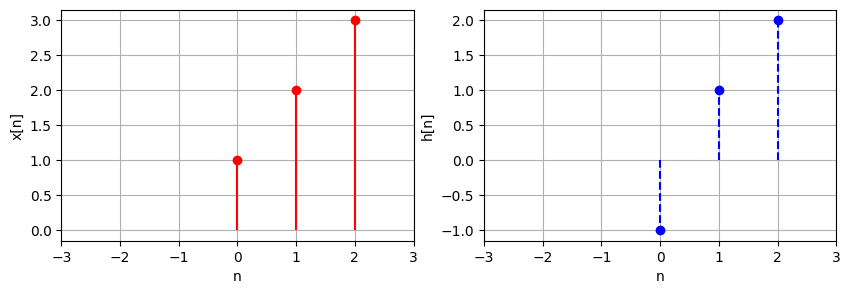

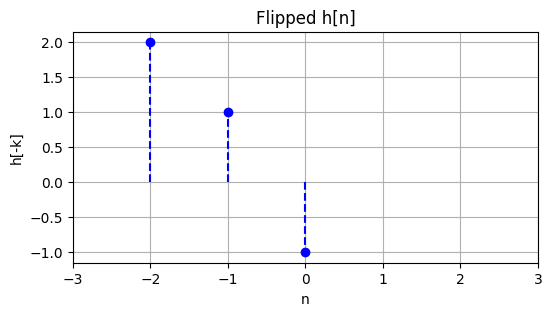

In [4]:
import matplotlib.pyplot as plt

x = np.array([1,2,3])
h = np.array([-1,1,2])

def stem_plot(ax, signal, origin=0, label="", linefmt=None, markerfmt=None):
    n = np.arange(origin, origin+len(signal))
    ax.stem(n, signal, linefmt=linefmt, markerfmt=markerfmt, basefmt=" ")
    ax.set_xlabel("n")
    ax.set_ylabel(label)
    ax.grid(True)
    ax.set_xlim(-3,3)

# Signals
fig, axs = plt.subplots(1,2, figsize=(10,3))
stem_plot(axs[0], x, 0, "x[n]", linefmt='r-', markerfmt='ro')
stem_plot(axs[1], h, 0, "h[n]", linefmt='b--', markerfmt='bo')
plt.show()

# Flipped h[-k]
h_flip = h[::-1]
fig, ax = plt.subplots(figsize=(6,3))
stem_plot(ax, h_flip, -len(h)+1, "h[-k]", linefmt='b--', markerfmt='bo')
plt.title("Flipped h[n]")
plt.show()


In [5]:
from ipywidgets import interact
steps = len(x) + len(h) - 1

def plot_convolution_step(n):
    fig, ax = plt.subplots(figsize=(6,3))


    ax.stem(np.arange(len(x)), x, linefmt='r-', markerfmt='ro', basefmt=" ", label="x[k]")


    n_axis = np.arange(n-len(h)+1, n+1)
    ax.stem(n_axis, h_flip, linefmt='b--', markerfmt='bo', basefmt=" ", label=f"h[n-k], n={n}")


    s = 0
    for k in range(len(x)):
        if 0 <= n-k < len(h):
            s += x[k] * h[n-k]

    ax.set_title(f"Shift n={n}, y[{n}] = {s}")
    ax.legend()
    ax.grid(True)
    ax.set_xlim(-3, len(x)+len(h))     # adjust as needed
    ax.set_ylim(-2, max(x.max(), h.max())+1)
    plt.show()


    print(f"Convolution value at n={n}: y[{n}] = {s}")

interact(plot_convolution_step, n=(0, steps-1));


interactive(children=(IntSlider(value=2, description='n', max=4), Output()), _dom_classes=('widget-interact',)…

Numpy has a built in convolution function.

In [ ]:
print("Using numpy:", np.convolve(x,h))

Using numpy: [-1 -1  1  7  6]


In [ ]:
# Compare correlation vs convolution
conv = np.convolve(x,h,mode='full')
print("Convolution (x,h):", conv)
conv = np.convolve(h,x,mode='full')
print("Convolution (h,x):", conv)
corr = np.correlate(x,h,mode='full')
print("Correlation (x,h):", corr)
corr = np.correlate(h,x,mode='full')
print("Correlation (h,x):", corr)

Convolution (x,h): [-1 -1  1  7  6]
Convolution (h,x): [-1 -1  1  7  6]
Correlation (x,h): [ 2  5  7  1 -3]
Correlation (h,x): [-3  1  7  5  2]


## Convolution Using Patchifying (Efficient Way)

In the loop-based method, convolution is computed by explicitly **shifting, multiplying, and summing**.  
This works, but is **slow** for long signals.

A more efficient way is to use the **patchifying (sliding window) approach**:
- We create **sliding windows** of the input signal \(x[n]\).
- Each window is multiplied with the **flipped kernel \(h[-n]\)**.
- The dot product of each window with the kernel gives one output sample.

This approach is very close to what happens inside **deep learning frameworks (CNNs)**,  
where convolution is implemented as a matrix multiplication of **patches × kernels**.

We’ll implement this using NumPy’s `sliding_window_view`.


Sliding windows:
 [[0 0 1]
 [0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 0]
 [5 0 0]]


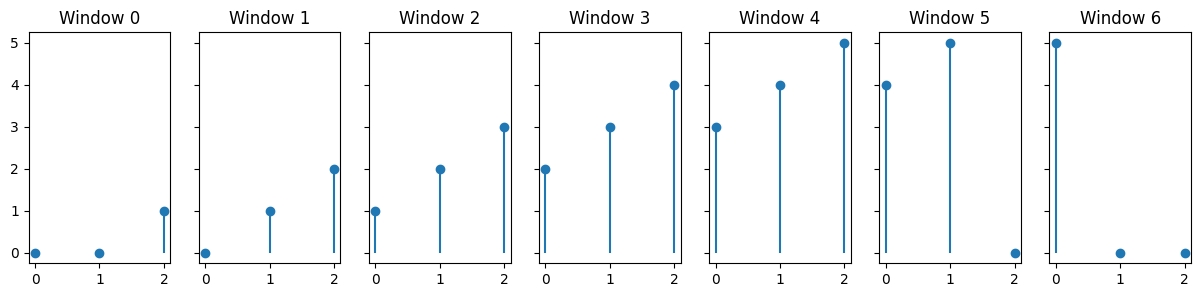

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

x = [1,2,3,4,5]
h = [1,0,-1]
windows = sliding_window_view(np.pad(x,(len(h)-1,len(h)-1)), len(h))
# np.pad adds zeros to both edges. Do you understand why it is needed?
print("Sliding windows:\n", windows)

fig, axs = plt.subplots(1, len(windows), figsize=(15,3), sharey=True)
for i, w in enumerate(windows):
    axs[i].stem(range(len(w)), w, basefmt=" ")
    axs[i].set_title(f"Window {i}")
plt.show()

In [ ]:
def conv_patchify(x, h):
    """
    Convolution using patchifying (sliding window).

    Equivalent to np.convolve(x, h, mode='full').
    """
    x = np.array(x)
    h = np.array(h)
    h_flip = h[::-1]

    # Full convolution length = N + M - 1
    N, M = len(x), len(h)

    # Pad input on both sides (M-1 zeros left, M-1 zeros right)
    x_padded = np.pad(x, (M-1, M-1))

    # Create sliding windows of length M
    patches = sliding_window_view(x_padded, M)

    # Compute dot products
    y = patches @ h_flip

    return y

In [ ]:
# Example
x = [1,2,3]
h = [-1,1,2]

y_patch = conv_patchify(x,h)
y_numpy = np.convolve(x,h,mode='full')

print("Patchify result:", y_patch)
print("Numpy result:   ", y_numpy)

Patchify result: [-1 -1  1  7  6]
Numpy result:    [-1 -1  1  7  6]


In [ ]:
import timeit
# Let's take a long random signal and a long random impulse response
x = np.random.randn(5000)
h = np.random.randn(100)

time_loop = timeit.timeit(lambda: conv_loop(x, h), number=1)
time_patch = timeit.timeit(lambda: conv_patchify(x, h), number=1)
time_numpy = timeit.timeit(lambda: np.convolve(x, h, mode='full'), number=1)

print("Runtime (seconds):")
print(f"Loop method:      {time_loop:.4f}")
print(f"Patchify method:  {time_patch:.6f}")
print(f"NumPy convolve:   {time_numpy:.6f}")

Runtime (seconds):
Loop method:      2.0630
Patchify method:  0.000944
NumPy convolve:   0.000203


- **Loop method**: Easy to understand, but **very slow** for large signals.
- **Patchify method**: Much faster (vectorized NumPy), patchify helps us understand **how CNNs implement convolution**
- **NumPy’s convolve**: Fastest.


## (Extra) 2D Convolution Using Patchifying

In 1D convolution:
- We created **sliding windows** of the signal.
- Took a **dot product** with the flipped kernel.

In 2D convolution (images):
- We create **sliding patches** of the image.
- Each patch is multiplied elementwise with the flipped 2D kernel.
- Summing these products gives one output pixel.

This is exactly how **image filters** (blurring, edge detection, sharpening) and  
**CNN layers** perform convolution.

<!-- Let’s try with a small synthetic 2D example. -->


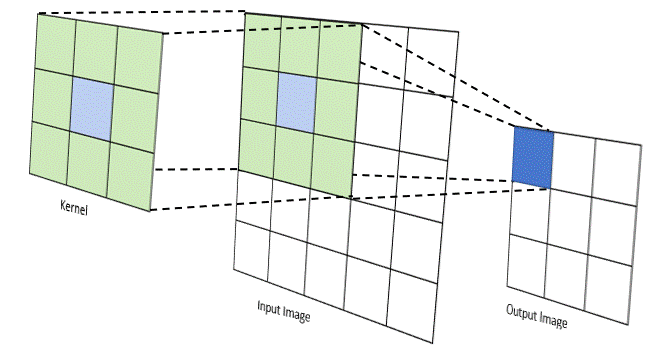

*Image collected from https://medium.com/@timothy_terati/image-convolution-filtering-a54dce7c786b*

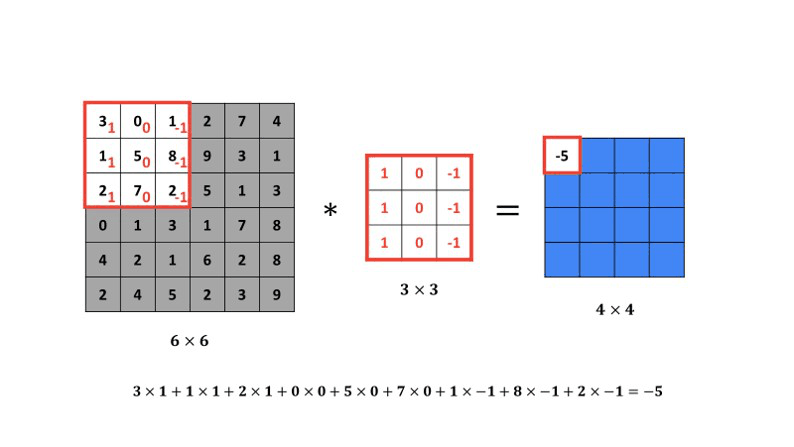

*Image collected from https://datahacker.rs/edge-detection/*

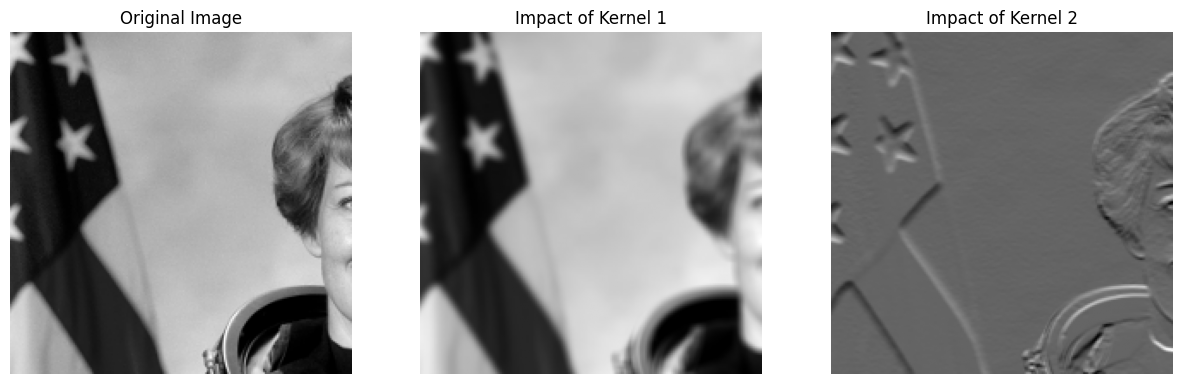

In [ ]:
from skimage import data, color
def conv2d_patchify(image, kernel):
    """
    2D convolution using patchifying (valid mode).
    """
    image = np.array(image, dtype=float)
    kernel = np.array(kernel, dtype=float)
    kH, kW = kernel.shape

    # Flip kernel
    kernel_flip = np.flipud(np.fliplr(kernel))

    # Extract sliding patches
    patches = sliding_window_view(image, (kH, kW))

    # Dot product
    H, W = patches.shape[:2]
    output = np.zeros((H, W))
    for i in range(H):
        for j in range(W):
            output[i,j] = np.sum(patches[i,j] * kernel_flip)

    return output

# Load a sample image (camera photo from skimage)
image = color.rgb2gray(data.astronaut())   # convert to grayscale
image = image[:200,:200]   # crop

# Example kernels
kernel_1 = np.ones((5,5)) / 25
kernel_2 = np.array([[-1,-1,-1],
                        [ 0, 0, 0],
                        [ 1, 1, 1]])

# Apply filters
blurred = conv2d_patchify(image, kernel_1)
edges = conv2d_patchify(image, kernel_2)


fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(blurred, cmap="gray")
axs[1].set_title("Impact of Kernel 1")
axs[1].axis("off")

axs[2].imshow(edges, cmap="gray")
axs[2].set_title("Impact of Kernel 2")
axs[2].axis("off")

plt.show()


We can see that the first kernel made the image blurry and the second kernel imphasized the edges. We call these operations low pass filtering and high pass filtering repectively.

## Filtering

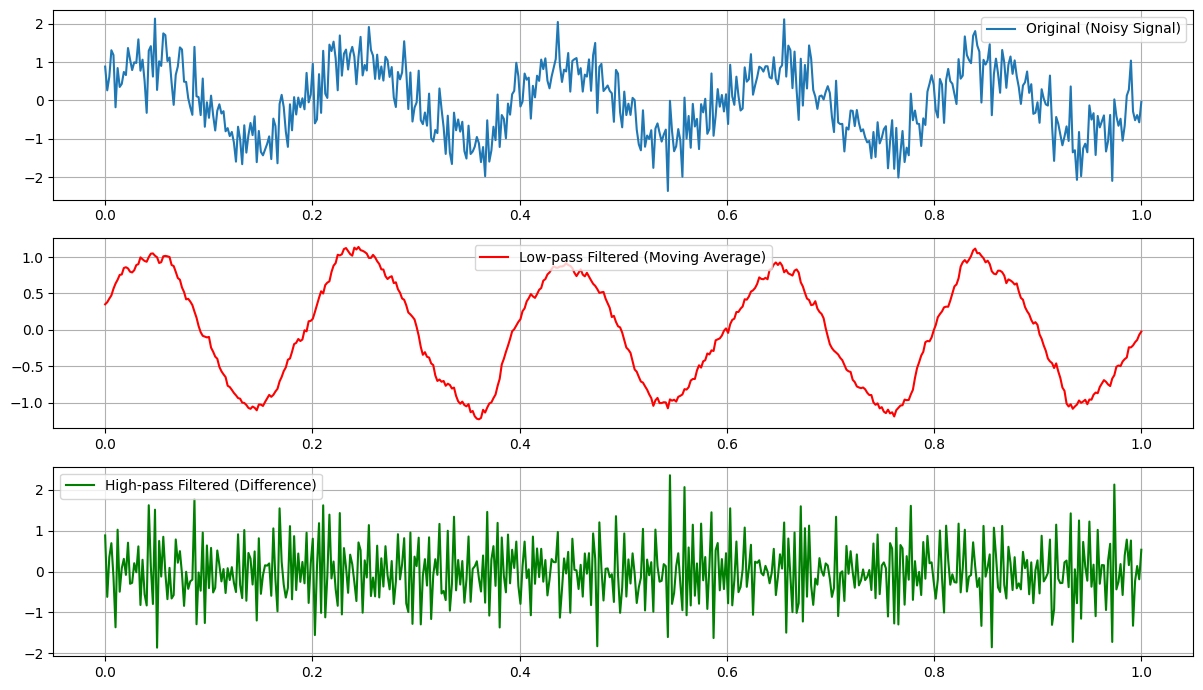

In [ ]:
# Create a noisy sinusoidal signal (like PPG-like waveform)
np.random.seed(0)
t = np.linspace(0, 1, 500)
signal = np.sin(2*np.pi*5*t) + 0.5*np.random.randn(len(t))

# Low-pass filter: Moving average
M = 15   # filter length
h_lp = np.ones(M)/M
signal_lp = np.convolve(signal, h_lp, mode='same')

# High-pass filter: Difference filter
h_hp = [1,-1]
signal_hp = np.convolve(signal, h_hp, mode='same')

# Plot results
plt.figure(figsize=(12,7))

plt.subplot(3,1,1)
plt.plot(t, signal, label="Original (Noisy Signal)")
plt.legend()
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, signal_lp, 'r', label="Low-pass Filtered (Moving Average)")
plt.legend()
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, signal_hp, 'g', label="High-pass Filtered (Difference)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Low pass filtering smoothes the signal while high pass filtering captures noise.

## Let's see the impact of filtering for an audio signal

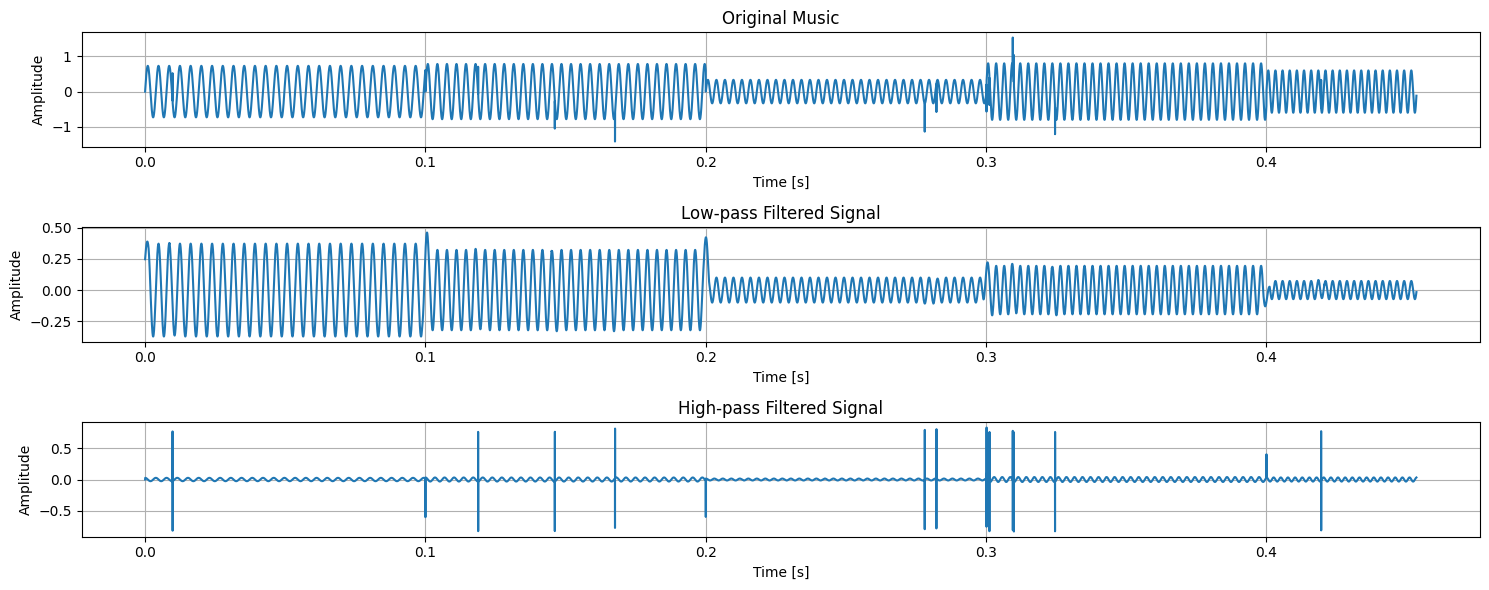


 Moving averaged music



 Difference filtered music


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def generate_sine_wave(freq, duration, amplitude, fs=44100):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    return amplitude * np.sin(2 * np.pi * freq * t)

# Musical notes and their corresponding frequencies (in Hz)]
notes_freqs = {
    'C': 261.63,  # C4
    'D': 293.66,  # D4
    'E': 329.63,  # E4
    'F': 349.23,  # F4
    'G': 392.00,  # G4
    'A': 440.00,  # A4
    'B': 493.88,  # B4
    'C5': 523.25, # C5
    'D5': 587.33, # D5
    'E5': 659.26  # E5
}

# Create a melody with a mix of lower and higher notes
melody_low = ['C', 'D', 'E', 'F', 'G', 'A', 'B']
melody_high = ['C5', 'D5', 'E5']

duration_per_note = 0.1  # in seconds

fs = 44100
audio_signal = np.array([])

for note in melody_low:
    amplitude = np.random.uniform(0.2, 1.0)
    audio_signal = np.concatenate((audio_signal, generate_sine_wave(notes_freqs[note], duration_per_note, amplitude, fs)))

for note in melody_high:
    base_amplitude = np.random.uniform(0.2, 0.9)
    high_freq_signal = generate_sine_wave(notes_freqs[note], duration_per_note, base_amplitude, fs)
    audio_signal = np.concatenate((audio_signal, high_freq_signal ))
# Add sudden changes (spikes)
num_spikes = 20
spike_amplitude = 0.8

for _ in range(num_spikes):
    spike_position = np.random.randint(0, len(audio_signal) - 1)  # Random position in the signal
    audio_signal[spike_position] += spike_amplitude * np.random.choice([-1, 1])  # Add spike of random polarity

# Low-pass filter: Moving average
M = 100  # Filter length
h_lp = np.ones(M) / M
signal_lp = np.convolve(audio_signal, h_lp, mode='same')

# High-pass filter: Difference filter
h_hp = [1,-1]
signal_hp = np.convolve(audio_signal, h_hp, mode='same')

# Number of samples to plot
N_plot = 20000

plt.figure(figsize=(15, 6))

plt.subplot(3, 1, 1)
plt.plot(np.linspace(0, N_plot/fs, N_plot), audio_signal[:N_plot])
plt.title("Original Music")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(np.linspace(0, N_plot/fs, N_plot), signal_lp[:N_plot])
plt.title("Low-pass Filtered Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(np.linspace(0, N_plot/fs, N_plot), signal_hp[:N_plot])
plt.title("High-pass Filtered Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Save the audio signals
wav.write('original_music.wav', fs, (audio_signal * 32767).astype(np.int16)) # multiplying 32767 to scale the floating-point audio
                                                                                                       # data to the range of 16-bit integers
wav.write('low_pass_filtered_music.wav', fs, (signal_lp * 32767).astype(np.int16))
wav.write('high_pass_filtered_music.wav', fs, (signal_hp * 32767).astype(np.int16))

# Play the original music
import IPython.display as ipd
ipd.display(ipd.Audio('original_music.wav'))
print("\n Moving averaged music")
ipd.display(ipd.Audio('low_pass_filtered_music.wav'))
print("\n Difference filtered music")
ipd.display(ipd.Audio('high_pass_filtered_music.wav'))


You can hear that the low passed audio signal is smoother than the original audio signal and the high passed audio mainly captures the sudden changes/spikes.

## Filtering extended(In frequency domain)

In signal processing, a digital filter is a system that performs mathematical operations on a sampled, discrete-time signal to reduce or enhance certain aspects of that signal, especially in the frequency domain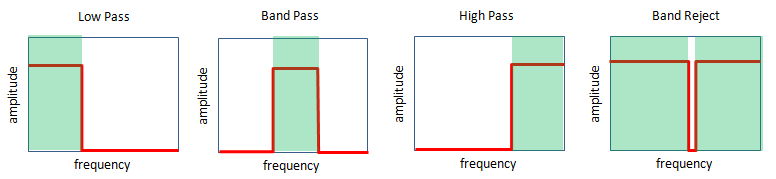

For this section, don't worry about the codes. We will deep dive into these codes in the later lab sessions. Just think like this, a signal can be represented as a summation of sinusoids of different frequencies (Fourier Transform). Fast Fourier Transform (FFT) takes a signal in time domain and returns its frequency domain representation.
Inverse Fast Fourier Transform (IFFT) takes a signal in frequency domain and returns its time domain representation.

In [ ]:
from numpy.fft import fft,fftshift, fftfreq, ifft, ifftshift

def perform_fft(x, N):
    X = fft(x)
    X = fftshift(X)
    X = X/N # Normalization

    fk = fftfreq(N)
    fk = fftshift(fk)

    return X, fk

def perform_ifft(X, N):
    X_ishift = ifftshift(X)
    x_recon = ifft(X_ishift)
    x_recon = np.real(x_recon)*N

    n = np.arange(N)
    if x_recon.shape[0] > N:
        x_recon = x_recon[:N]

    return x_recon, n

def plot_sig_and_fft(x, n, X, fk):
    fig = plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)
    plt.plot(n, x)
    plt.xlabel("$n$")
    plt.ylabel("$x[n]$")
    plt.title(f"Signal in time domain")

    plt.subplot(1, 2, 2)
    plt.stem(fk, np.abs(X))
    plt.xlabel("Digital frequncy")
    plt.title("Signal in frequency domain")

Now, we are deliberately taking a signal which is a summation of 3 sinusoids of different frequencies to see the impact of filtering.

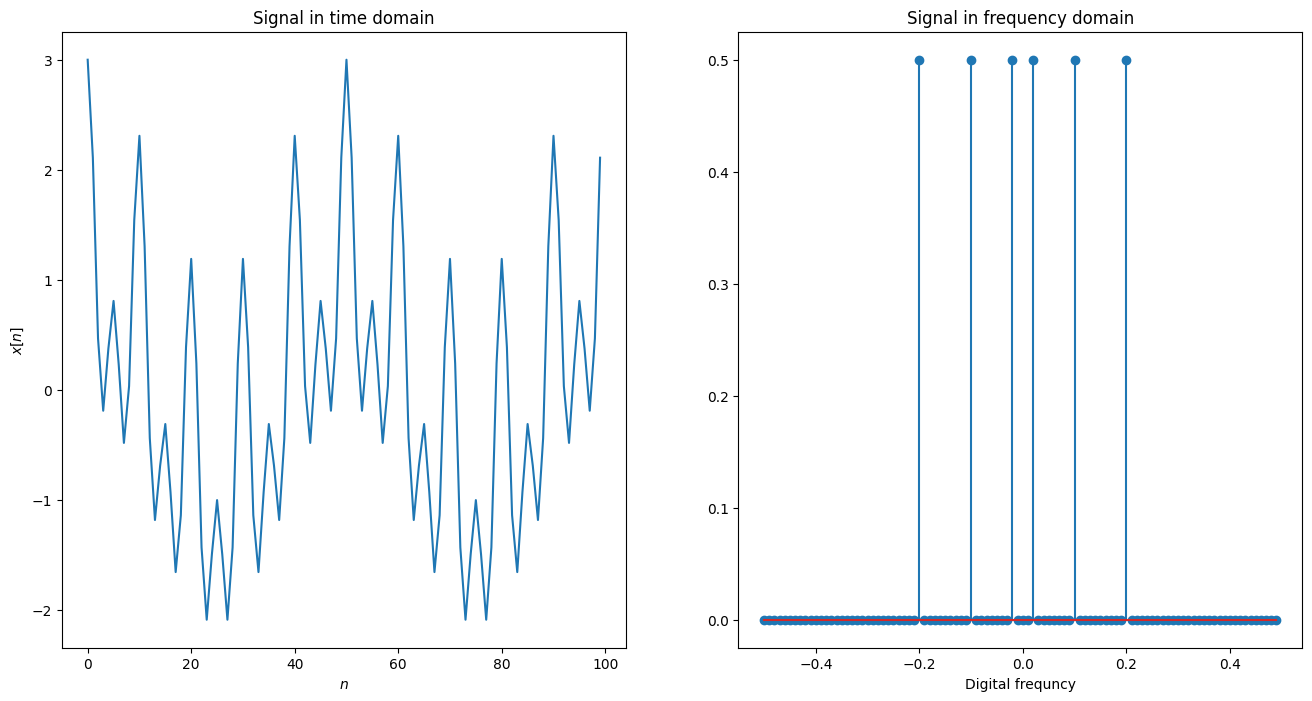

In [ ]:
f1 = 0.02
f2 = 0.1
f3 = 0.2
N=100
n = np.arange(N)
x = np.cos(2*np.pi*f1*n) + np.cos(2*np.pi*f2*n) + np.cos(2*np.pi*f3*n)

X, fk = perform_fft(x, N)
plot_sig_and_fft(x, n, X, fk)

**Ideal Low Pass Filter**




Low pass filter keeps the frequency contents lower than a threshold and discards the higher frequency contents.

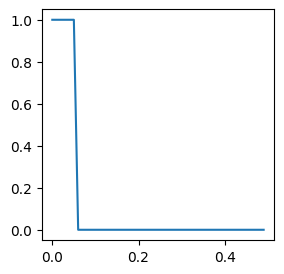

In [ ]:
f_thres = 0.05

H_lp_ideal = np.zeros_like(fk)
H_lp_ideal[np.abs(fk) <= f_thres] = 1

fig = plt.figure(figsize=(3, 3))
plt.plot(fk[fk>=0], H_lp_ideal[fk>=0])

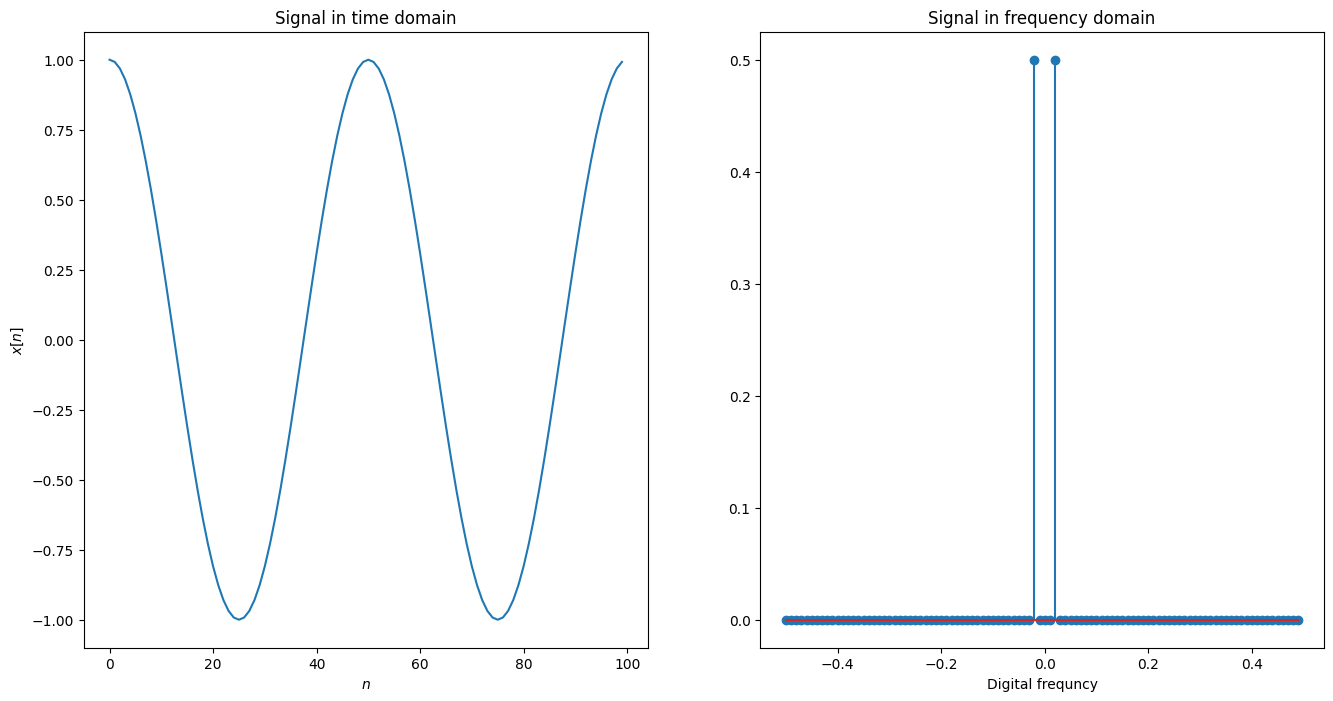

In [ ]:
X_filtered_1 = X*H_lp_ideal
x_recon, n_recon = perform_ifft(X_filtered_1, N)
plot_sig_and_fft(x_recon, n_recon, X_filtered_1, fk)

As we set the threshold as 0.05, filtering only preserved the 0.02 frequency content. So, we are now seeing a proper sinusoid.

**Butterworth Low-Pass Filter Equation**

A Butterworth filter of order \( n \) with cutoff frequency \( f_c \) has a magnitude response given by:

$$
H(f) = \frac{1}{\sqrt{1 + \left( \frac{f}{f_c} \right)^{2n}}}
$$

- \( H(f) \): Filter gain at frequency \( f \)  
- \( f_c \): Cutoff frequency  
- \( n \): Filter order — higher \( n \) means sharper roll-off


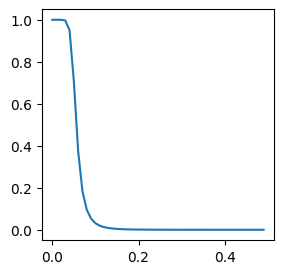

In [ ]:
f_thres = 0.05

N_ord = 5
H_lp_butter = 1/np.sqrt(1 + (fk/f_thres)**(2*N_ord))

fig = plt.figure(figsize=(3, 3))
plt.plot(fk[fk>=0], H_lp_butter[fk>=0])

Why butterworth filter is  needed?

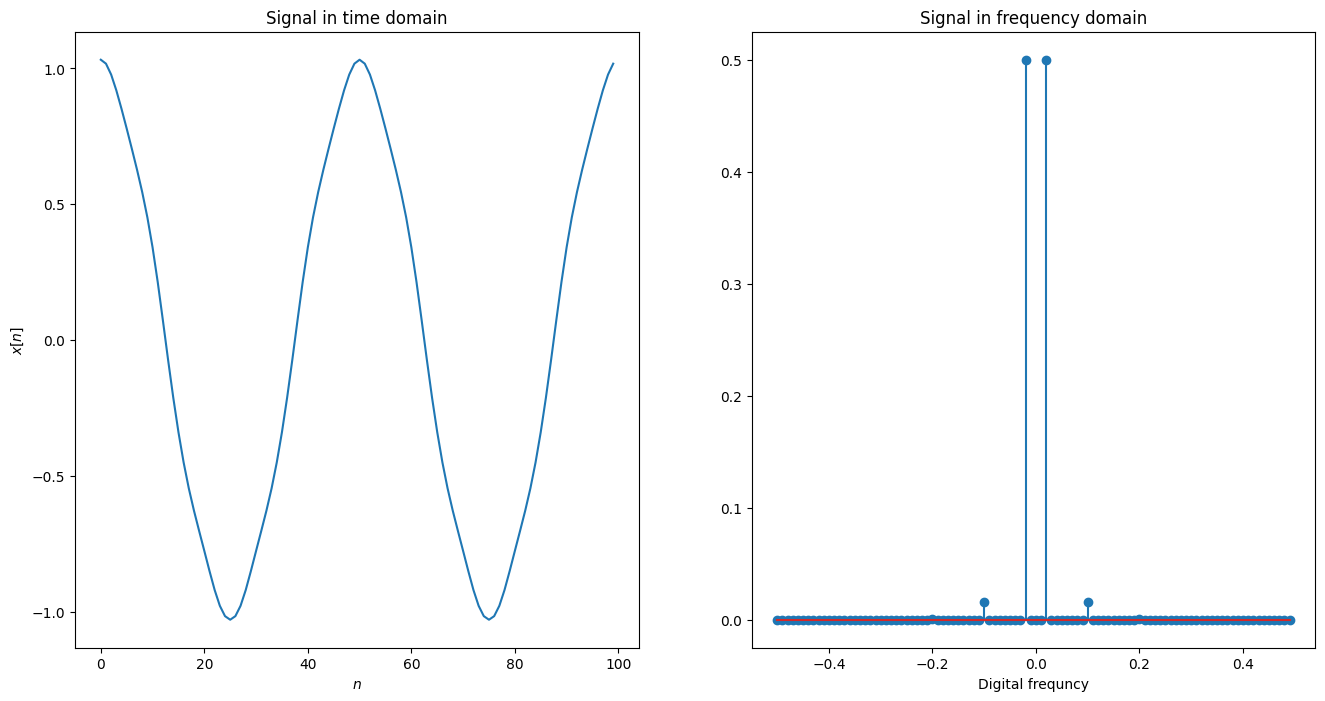

In [ ]:
X_filtered_1 = X*H_lp_butter
x_recon, n_recon = perform_ifft(X_filtered_1, N)
plot_sig_and_fft(x_recon, n_recon, X_filtered_1, fk)

Now, think how you can produce a high pass and bandpass filter using the low pass filter?

***We will now apply these filtering techniques to a biomedical signal***

The signal is generated from 'ECG PPG Arrythmia Simulator'. The simulator provides a mathematical modeling of ECG and PPG based on real signals and you can set some parameters to generate your desired types of signals for example PPG/ECG for a certain disease condition.
You can find the details here: https://physionet.org/content/ecg-ppg-simulator-arrhythmia/1.3.1/


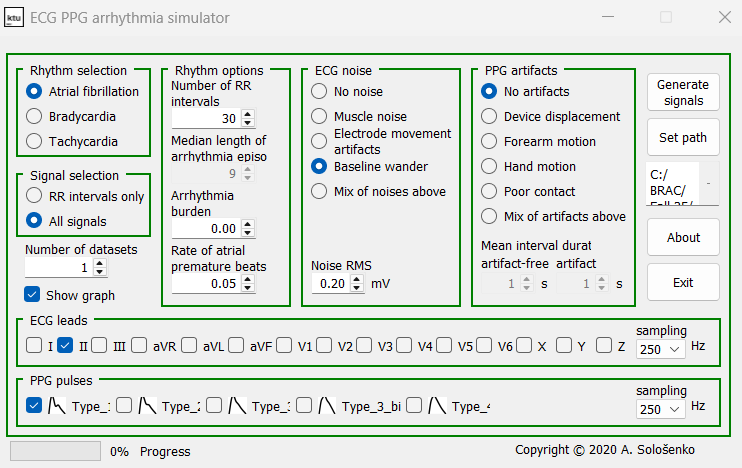

The above picture shows the parameters used for the file we are going to handle next. You don't need to understand everything here, some intuition is enough for now.

ECG length: 5827
PPG length: 6361


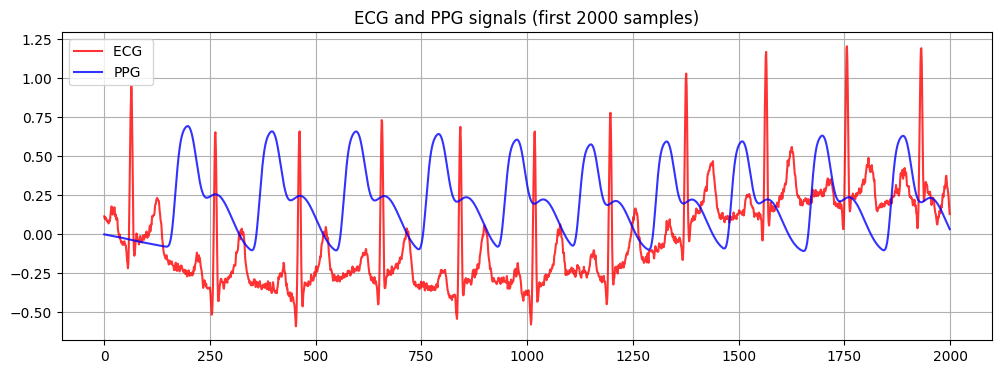

In [ ]:
from scipy.io import loadmat

filename='/content/AF_20251027_131853_658298.mat'
data = loadmat(filename, struct_as_record=False, squeeze_me=True)
signals = data['signals']

ecg_cell = signals.multileadECG

# Convert MATLAB cell (object array) to 1D numpy array (No need to worry about this)
if isinstance(ecg_cell, np.ndarray) and ecg_cell.dtype == np.object_:
    ecg = np.array([float(x) for x in ecg_cell.flatten()])
else:
    ecg = np.asarray(ecg_cell).squeeze()
ppg = np.asarray(signals.PPG).squeeze()

print("ECG length:", len(ecg))
print("PPG length:", len(ppg))

plt.figure(figsize=(12, 4))
plt.plot(ecg[:2000], label='ECG ', color='r', alpha=0.8)
plt.plot(ppg[:2000], label='PPG', color='b', alpha=0.8)
plt.title("ECG and PPG signals (first 2000 samples)")
plt.legend()
plt.grid(True)
plt.show()

If you observe the ecg signal, the baseline is fluctuating. It can cause errors in cases like heart rate estimation as we need the distance between the peaks of successive beats but here peaks can be misclassified. The ecg is also a bit noisy. We want to filter the signal to overcome the issues.

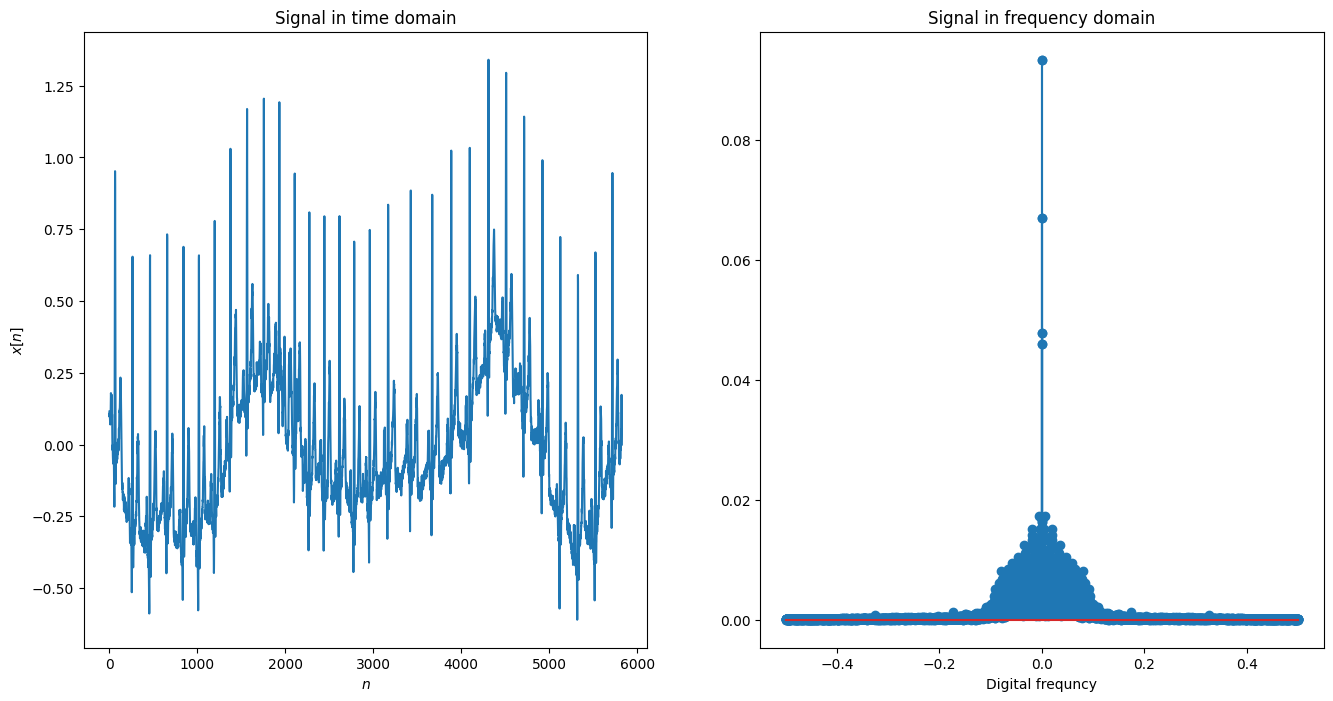

In [ ]:
X,fk=perform_fft(ecg, len(ecg))
plot_sig_and_fft(ecg, np.arange(len(ecg)), X, fk)

A normal ecg contains frequency contents ranging from 0.5~40Hz. We are observing a peak in very low frequency (almost zero). It is causing the baseline shift. We can bandpass the ecg to solve this.

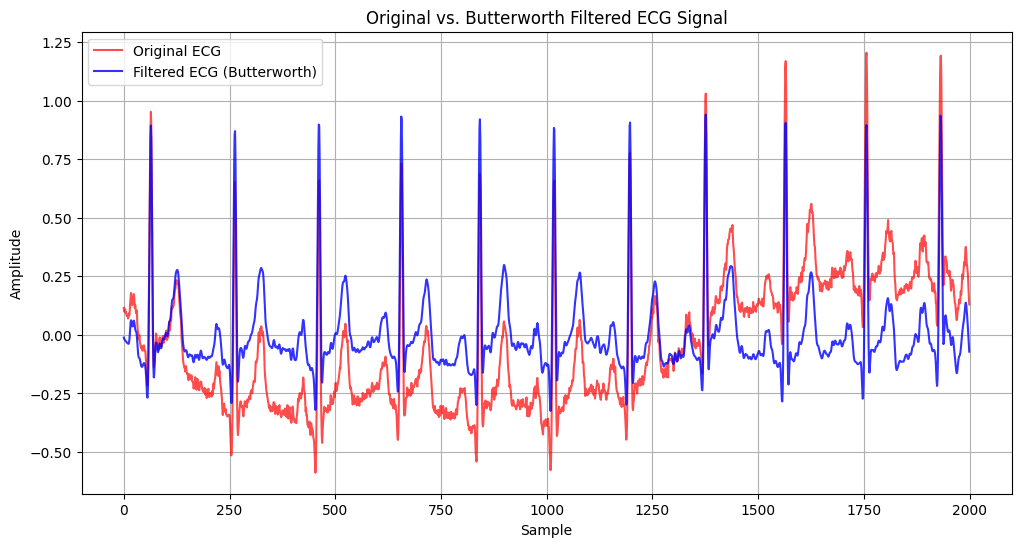

In [ ]:
from scipy.signal import butter, filtfilt
# Apply Butterworth filter to ECG
fs = 250.0
lowcut = 0.5  # Low cutoff frequency in Hz
highcut = 40.0 # High cutoff frequency in Hz
order = 5      # Filter order

# Calculate the Nyquist frequency
nyq = 0.5 * fs

# Normalize the cutoff frequencies to the Nyquist frequency
low = lowcut / nyq
high = highcut / nyq

# Get the filter coefficients
b, a = butter(order, [low, high], btype='band')

# Apply the filter to the ECG signal
ecg_filtered = filtfilt(b, a, ecg)

plt.figure(figsize=(12, 6))
plt.plot(ecg[:2000], label='Original ECG', color='r', alpha=0.7)
plt.plot(ecg_filtered[:2000], label='Filtered ECG (Butterworth)', color='b', alpha=0.8)
plt.title("Original vs. Butterworth Filtered ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

This time we applied the butterworth filter from the scipy library. We can see that the filtered ecg is smoother (high frequency noise eliminated) and baseline wandering is also solved (by eliminating low frequency contents)